# Deep Operator Network

Deep Operator Networks (DeepONets) learn the operator that maps a set of functions to another function. Using the same PDE as the [PINN](pinn.ipynb) and [P$^2$INN](parametrized_pinn.ipynb) examples, we will learn the mapping $G: \{N(t), g_0(x)\} \rightarrow g(x,t)$, where $N(t)$ is the relative population size change and $g_0$ is the initial condition of the PDE. Our model's coordinate inputs will be $(x,t)$, as before, and the auxiliary inputs will be arrays of $N(t)$ and $g_0(x)$ evaluated at fixed $t_s$ and $x_s$ sensor points. 

As before, we will enforce $N(t = 0) = 1$ and choose a linear population size change function, $N(t, N_s) = N_s t + 1$.  We will evaluate $N(t, N_s)$ for different $N_s$ values and across a fixed set of sensor points $t_s$. The resulting array will have a shape `(NUM_NS_PTS, NUM_TS_PTS)`. 

Because $N(t = 0) = 1$, the initial condtion 

$$
g_0(x) = \theta\frac{1 - e^{-2\gamma(1-x)}}{1 - e^{-2\gamma}}.
$$

only depends on $\gamma$, so we can construct our training data by varying $\gamma$ and evaluating $g_(x, \gamma)$ across a fixed set of sensor points $x_s$. The resulting data array will have a shape `(NUM_G_PTS, NUM_XS_PTS)`.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)  # PINNs generally need float64
import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from jaxtyping import Array

from popinn import AdamConfig, FixedWeights, LBFGSConfig, Loss, ResidualTerm, plot_training_history, train_model, warmup_cosine

In [98]:
# Fixed values

THETA = 1.0  # population-scaled mutation rate
NFUNC = lambda t, N_s: N_s * t + 1.0  # linear population size increase

# gamma bounds
GMIN = 0.0
GMAX = 5.0

# gamma grid length
NUM_G_PTS = 30
NUM_XS_PTS = 31

# N_s bounds:
NS_MIN = 0.0
NS_MAX = 10.0

# N_s grid length
NUM_NS_PTS = 31
NUM_TS_PTS = 30

# x-coordinate bounds
XMIN = 0.0
XMAX = 1.0

# t-coordinate maximum
TMAX = 1.0

# colocation grid lengths
NUM_PDE_PTS = 32  # points per spatial/temporal coordinate axis on PDE interior
NUM_EDGE_PTS = 256  # points used to sample the IC/boundary coordinate lines

## Residual Terms

In this example, $\gamma$ is an *auxiliary input* of our model. This means it will be passed through the `aux` argument of our residual factory and all we need to do is replace any instances of the fixed `GAMMA` value with the value in `aux` and make sure `aux` is now passed as an argument in any `model` calls:

In [99]:
def unpack(aux):
    (Nvals_, Ns_), (ics_, gamma_) = aux
    return (Nvals_, ics_), Ns_, gamma_

In [100]:
# PDE residual
def pde_residual(model):
    def r(x, t, sup_aux):
        aux, Ns, gamma = unpack(sup_aux)  # unpack gamma from the aux tuple

        dg_dx = model.D(0)(x, t, aux)  # d/dx
        dg_dt = model.D(1)(x, t, aux)  # d/dt
        d2g_dx2 = model.D(0, 0)(x, t, aux)  # d2/dx2

        diff = x * (1.0 - x) / (2.0 * NFUNC(t, Ns)) * d2g_dx2  # diffusion
        sel = gamma * x * (1.0 - x) * dg_dx  # selection

        # we weight the per-point residuals by their frequency x, as the gradients
        # tend to be very large at low-frequency. Wrapping x in
        # jax.lax.stop_gradient treats it like a constant, rather than a differentiable
        # quantity, so it doesn't change the PDE we are trying to solve
        return (dg_dt + sel - diff) * jax.lax.stop_gradient(x)

    return r

!!! Example "Important syntax note"
    We only unpack the `aux` tuple if an equation, like the PDE, needs the value in `aux`. You must still pass the full `aux` tuple to the `model` call. 
    For example, this is wrong and will throw an error:
    ```python
    gamma, = aux
    dg_dx = model.D(0)(x, t, gamma) # this errors because gamma is not a tuple
    sel  = gamma * x * (1.0 - x) * dg_dx
    ```
    but this is correct and will not:
    ```python
    gamma, = aux
    dg_dx = model.D(0)(x, t, aux)
    sel  = gamma * x * (1.0 - x) * dg_dx # gamma, not aux is the correct thing to multiply here
    ```

In [101]:
# Left BC residual
def left_bc_residual(model):
    def r(x, t, sup_aux):
        aux, Ns, gamma = unpack(sup_aux)
        return model(x, t, aux) - THETA * NFUNC(t, Ns)

    return r

In [102]:
# Right BC residual
def right_bc_residual(model):
    def r(x, t, sup_aux):
        aux, Ns, gamma = unpack(sup_aux)
        return model(x, t, aux)

    return r

In [103]:
def initial_g(x, _gamma):
    neutral = 1.0 - x
    selected = jnp.expm1(-2.0 * _gamma * (1.0 - x)) / jnp.expm1(-2.0 * _gamma)
    # jnp.where keeps this differentiable and vmap-friendly across gamma.
    return THETA * jnp.where(jnp.greater(jnp.abs(_gamma), 1e-5), selected, neutral)


# initial condition residual
def ic_residual(model):
    def r(x, t, sup_aux):
        aux, Ns, gamma = unpack(sup_aux)
        return model(x, t, aux) - initial_g(x, gamma)

    return r

The `Loss` initialization stays the same:

In [104]:
weights = FixedWeights({"pde": 1000, "ic": 100, "left_bc": 100, "right_bc": 1})

In [105]:
total_loss = Loss(
    [
        ResidualTerm(name="pde", residual_fn=pde_residual),
        ResidualTerm(name="left_bc", residual_fn=left_bc_residual),
        ResidualTerm(name="right_bc", residual_fn=right_bc_residual),
        ResidualTerm(name="ic", residual_fn=ic_residual),
    ],
    # weights = weights
)

## Training Data

This time, we pass the array of $\gamma$ values to `aux` in our data container:

In [106]:
class TrainingData(eqx.Module):
    pde_coords: tuple[Array]
    ic_coords: tuple[Array]
    left_bc_coords: tuple[Array]
    right_bc_coords: tuple[Array]
    aux: tuple


X_pde = jnp.linspace(XMIN, XMAX, NUM_PDE_PTS)
T_pde = jnp.linspace(0, TMAX, NUM_PDE_PTS)

X_ic = jnp.linspace(XMIN, XMAX, NUM_EDGE_PTS)
T_ic = jnp.zeros(1)

T_bc = jnp.linspace(0, TMAX, NUM_EDGE_PTS)
X_lbc = XMIN * jnp.ones(1)
X_rbc = XMAX * jnp.ones(1)

# all of the above is the same as before
# Get the N(t) array
TS = jnp.linspace(0, TMAX, NUM_TS_PTS)
NS = jnp.linspace(NS_MIN, NS_MAX, NUM_NS_PTS)
NVALS = jax.vmap(NFUNC, in_axes=(None, 0))(TS, NS)
assert NVALS.shape == (NUM_NS_PTS, NUM_TS_PTS)

# Get the g_0(x) array
XS = jnp.linspace(XMIN, XMAX, NUM_XS_PTS)
GAMMA = jnp.linspace(GMIN, GMAX, NUM_G_PTS)
ICVALS = jax.vmap(initial_g, in_axes=(None, 0))(XS, GAMMA)
assert ICVALS.shape == (NUM_G_PTS, NUM_XS_PTS)


data = TrainingData(
    pde_coords=(X_pde, T_pde),
    ic_coords=(X_ic, T_ic),
    left_bc_coords=(X_lbc, T_bc),
    right_bc_coords=(X_rbc, T_bc),
    aux=((NVALS, NS), (ICVALS, GAMMA)),  # pass gamma as an auxiliary input
)

!!! FAQ "Axis mapping and batching"
    Now, the loss will be evaluated over the outer-product of the coordinate axes and the `gamma` auxiliary axis. The materialized memory will scale as `NUM_PDE_PTS * NUM_PDE_PTS * NUM_G_PTS` in both the loss and gradient computations, so be careful with how large you make your grid lengths. 
    
    To reduce the materialized memory at the expensive of compute time, you use the `batch_size` keyword in `ResidualTerm` to batch over the last element's outer axis in `aux`. For example, if `NUM_G_PTS = 1000`, we could set `batch_size = 10` so that the materialized memory scales as `NUM_PDE_PTS * NUM_PDE_PTS * 10`, rather than `NUM_PDE_PTS * NUM_PDE_PTS * 100`. For now, we'll keep `NUM_G_PTS` small an save the batching for the DeepONet example.

## Initialize Model and Train

We'll first train with 500 Adam steps, then 1k of L-BFGS:

In [108]:
key = jr.PRNGKey(3)
from popinn import DeepONet

model = DeepONet(key, branch_input_dim=(NUM_TS_PTS, NUM_XS_PTS), trunk_input_dim=2, branch_depth=(5, 5))


model, history = train_model(
    model,
    data,
    total_loss,
    [AdamConfig(log_every=500, num_epochs=1000, lr=warmup_cosine(peak_lr=1e-3, num_epochs=1000)), LBFGSConfig(log_every=500, num_epochs=1000)],
)

[Adam] Starting (1000 epochs)
[Adam] Epoch      1 | total: 2.48e+01 | ic: 2.08e+00  left_bc: 2.23e+01  pde: 1.95e-06  right_bc: 4.16e-01
[Adam] Epoch    500 | total: 2.83e-01 | ic: 4.43e-02  left_bc: 1.47e-02  pde: 2.05e-01  right_bc: 1.93e-02
[Adam] Epoch   1000 | total: 1.88e-01 | ic: 3.19e-02  left_bc: 1.99e-02  pde: 1.12e-01  right_bc: 2.42e-02
[L-BFGS] Starting (1000 max iterations)
[L-BFGS] Step      1 | total: 1.88e-01 | ic: 3.18e-02  left_bc: 2.04e-02  pde: 1.12e-01  right_bc: 2.38e-02
[L-BFGS] Step    500 | total: 8.50e-02 | ic: 1.69e-02  left_bc: 3.76e-03  pde: 4.69e-02  right_bc: 1.75e-02
[L-BFGS] Step   1000 | total: 5.98e-02 | ic: 1.06e-02  left_bc: 2.87e-03  pde: 3.70e-02  right_bc: 9.41e-03


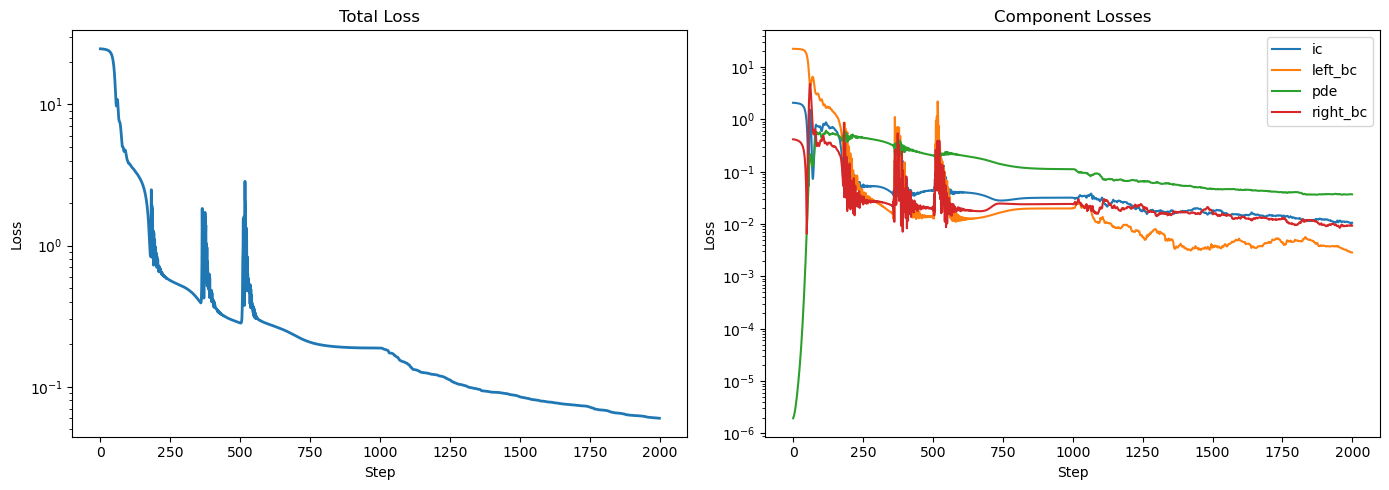

In [109]:
plot_training_history(history)

We'll check our trained solution at $t = 1$ against a numerical solver, specifically the solver included in the [`dadi`](https://github.com/RyanGutenkunst/dadi) package. `dadi` works in the untransformed frequency $\phi(x,t)$, so we'll need to multiply it by $x(1-x)$ to convert it to $g(x,t)$

In [110]:
import dadi

TEST_GAMMA = 2.7
TEST_IC = initial_g(XS, TEST_GAMMA)
TEST_NS = 3.0
TEST_NVALS = NFUNC(TS, TEST_NS)


def calc_dadi(tf=1.0, pts=300):
    xx = dadi.Numerics.default_grid(pts=pts)
    phi0 = dadi.PhiManip.phi_1D(xx, gamma=TEST_GAMMA)
    phif = dadi.Integration.one_pop(phi0, xx, tf, lambda t: NFUNC(t, TEST_NS), gamma=TEST_GAMMA)
    return xx, phif, phi0

In [118]:
x_dadi, phi_dadi, phi0_dadi = calc_dadi()
g_test = jax.vmap(model, in_axes=(0, None, None))(X_pde, 1.0, (TEST_NVALS, TEST_IC))

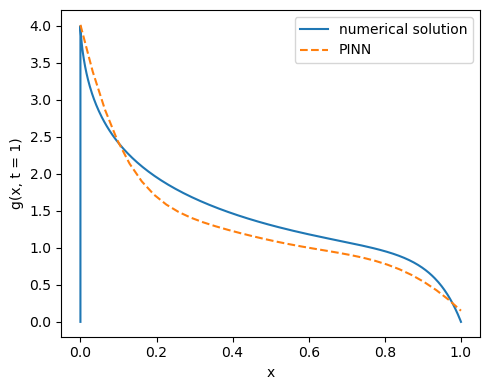

In [119]:
plt.figure(figsize=(5, 4))
plt.plot(x_dadi, phi_dadi * x_dadi * (1.0 - x_dadi), label="numerical solution")  # convert phi to g
plt.plot(X_pde, g_test, label="PINN", ls="--")
plt.legend()
plt.xlabel("x")
plt.ylabel("g(x, t = 1)")
plt.tight_layout()